
### NHS A&E 4-Hour Performance — Regression Analysis
### Predicts the EXACT 4-hr performance percentage for each NHS provider
### Data: Quarter 4 2025/26 — Provider Level


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "./"


### 1. LOAD & CLEAN


In [2]:
print("Loading data...")
df = pd.read_csv(DATA_DIR + "Provider_Level_Data.csv")
df = df[df["Code"] != "-"].copy().reset_index(drop=True)

col_map = {
    "A&E attendances - Type 1 Departments - Major A&E":        "type1_attendances",
    "Type 2 Departments - Single Specialty":                    "type2_attendances",
    "Type 3 Departments - Other A&E/Minor Injury Unit":         "type3_attendances",
    "Total attendances":                                        "total_attendances",
    "Total Attendances > 4 hours":                              "total_gt4h",
    "Percentage of attendances within 4 hours - Percentage in 4 hours or less (all)": "pct_within_4h_all",
    "Emergency Admissions - Emergency Admissions via Type 1 A&E": "emerg_admissions_t1",
    "Other Emergency admissions (i.e not via A&E)":             "other_emerg_admissions",
    "Total Emergency Admissions":                               "total_emerg_admissions",
    "Number of patients spending >4 hours from decision to admit to admission":  "pts_gt4h_dta",
    "Number of patients spending >12 hours from decision to admit to admission": "pts_gt12h_dta",
}
df.rename(columns=col_map, inplace=True)
df["pct_within_4h_all"] = pd.to_numeric(df["pct_within_4h_all"], errors="coerce")
print(f"  {len(df)} providers loaded | {df['pct_within_4h_all'].isna().sum()} missing target values")


Loading data...
  199 providers loaded | 9 missing target values



### 2. FEATURE ENGINEERING (leakage-free)


In [3]:
print("\nEngineering features...")

s = lambda a, b: a / b.replace(0, np.nan)
df["admission_rate"]  = s(df["total_emerg_admissions"], df["total_attendances"])
df["t1_share"]        = s(df["type1_attendances"],      df["total_attendances"])
df["t2_share"]        = s(df["type2_attendances"],      df["total_attendances"])
df["t3_share"]        = s(df["type3_attendances"],      df["total_attendances"])
df["dta_4h_rate"]     = s(df["pts_gt4h_dta"],           df["total_attendances"])
df["dta_12h_rate"]    = s(df["pts_gt12h_dta"],          df["total_attendances"])
df["log_total"]       = np.log1p(df["total_attendances"])

# Interaction features
df["t1_x_adm"]        = df["t1_share"]    * df["admission_rate"]
df["dta_x_t1"]        = df["dta_4h_rate"] * df["t1_share"]

# Binary complexity flag
df["high_complexity"] = ((df["t1_share"] > 0.5) & (df["admission_rate"] > 0.2)).astype(int)

# Encode region
le = LabelEncoder()
df["region_enc"] = le.fit_transform(df["Region"].fillna("Unknown"))

# NOTE: gt4h_rate, total_lt4h, total_gt4h are EXCLUDED — they are algebraic transforms of the target
FEATURES = [
    "total_attendances", "log_total",
    "type1_attendances", "type2_attendances", "type3_attendances",
    "admission_rate", "t1_share", "t2_share", "t3_share",
    "dta_4h_rate", "dta_12h_rate",
    "total_emerg_admissions", "other_emerg_admissions",
    "region_enc", "t1_x_adm", "dta_x_t1", "high_complexity",
]
TARGET = "pct_within_4h_all"

df_m = df.dropna(subset=FEATURES + [TARGET]).copy().reset_index(drop=True)
X, y  = df_m[FEATURES], df_m[TARGET]
print(f"  Modelling dataset: {len(df_m)} providers | {len(FEATURES)} features")


Engineering features...
  Modelling dataset: 190 providers | 17 features



### 3. TRAIN / TEST SPLIT


In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

scaler    = StandardScaler()
X_tr_s    = scaler.fit_transform(X_tr)
X_te_s    = scaler.transform(X_te)
X_s       = scaler.transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)


### 4. MODEL TRAINING & EVALUATION


In [5]:
print("\nTraining models...")

models = {
    "Ridge":             (Ridge(alpha=10.0),                                            True),
    "ElasticNet":        (ElasticNet(alpha=0.01, l1_ratio=0.5),                         True),
    "Random Forest":     (RandomForestRegressor(n_estimators=300, max_depth=6,
                                                min_samples_leaf=3, random_state=42,
                                                n_jobs=-1),                             False),
    "Gradient Boosting": (GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                                    learning_rate=0.03, subsample=0.8,
                                                    random_state=42),                  False),
    "XGBoost":           (XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.03,
                                       subsample=0.8, random_state=42, verbosity=0),   False),
}

results = {}
print(f"\n{'Model':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'CV R²':>8}")
print("─" * 60)

for name, (mdl, is_linear) in models.items():
    Xtr  = X_tr_s if is_linear else X_tr
    Xte  = X_te_s if is_linear else X_te
    Xall = X_s    if is_linear else X

    mdl.fit(Xtr, y_tr)
    pred  = np.clip(mdl.predict(Xte), 0, 1)
    rmse  = np.sqrt(mean_squared_error(y_te, pred)) * 100
    mae   = mean_absolute_error(y_te, pred) * 100
    r2    = r2_score(y_te, pred)
    cv_r2 = cross_val_score(mdl, Xall, y, cv=kf, scoring="r2").mean()

    results[name] = {
        "model": mdl, "rmse": rmse, "mae": mae, "r2": r2,
        "cv_r2": cv_r2, "pred_test": pred, "is_linear": is_linear,
    }
    print(f"{name:<22} {rmse:>7.2f}% {mae:>7.2f}% {r2:>8.4f} {cv_r2:>8.4f}")

best_name = max(results, key=lambda k: results[k]["cv_r2"])
print(f"\n✅ Best model: {best_name}  (CV R²={results[best_name]['cv_r2']:.4f})")

# Feature importances for tree-based models
print("\n── Feature importances (Random Forest) ──")
fi_labels = {
    "dta_4h_rate":             "4-hr DTA rate",
    "dta_x_t1":                "DTA × T1 share (interaction)",
    "type1_attendances":       "Type 1 attendances",
    "total_emerg_admissions":  "Total emergency admissions",
    "t1_x_adm":                "T1 share × Admission rate (interaction)",
    "t1_share":                "Type 1 dept share",
    "dta_12h_rate":            "12-hr DTA rate",
    "admission_rate":          "Admission rate",
    "t3_share":                "Type 3 dept share",
    "log_total":               "Log total attendances",
    "total_attendances":       "Total attendances",
    "type2_attendances":       "Type 2 attendances",
    "type3_attendances":       "Type 3 attendances",
    "t2_share":                "Type 2 dept share",
    "other_emerg_admissions":  "Other emergency admissions",
    "region_enc":              "Region",
    "high_complexity":         "High complexity flag",
}
rf_mdl = results["Random Forest"]["model"]
fi = pd.Series(rf_mdl.feature_importances_, index=FEATURES)
fi.index = [fi_labels.get(i, i) for i in fi.index]
print(fi.sort_values(ascending=False).head(10).round(4).to_string())


Training models...

Model                      RMSE      MAE       R²    CV R²
────────────────────────────────────────────────────────────
Ridge                     3.49%    2.80%   0.9333   0.8807
ElasticNet                3.45%    2.80%   0.9347   0.8817
Random Forest             3.25%    2.37%   0.9422   0.8923
Gradient Boosting         3.59%    2.62%   0.9293   0.8718
XGBoost                   3.77%    2.87%   0.9222   0.8736

✅ Best model: Random Forest  (CV R²=0.8923)

── Feature importances (Random Forest) ──
4-hr DTA rate                              0.2534
DTA × T1 share (interaction)               0.2275
Type 1 attendances                         0.1264
Total emergency admissions                 0.1167
T1 share × Admission rate (interaction)    0.0950
Type 1 dept share                          0.0792
12-hr DTA rate                             0.0442
Admission rate                             0.0238
Type 3 dept share                          0.0153
Type 3 attendances        


### 5. RESIDUAL ANALYSIS


In [6]:
print("\n── Residual analysis (best model on test set) ──")
best_res = results[best_name]
residuals = y_te.values - best_res["pred_test"]
print(f"  Mean error  : {np.mean(residuals)*100:+.2f}%")
print(f"  Std of error: {np.std(residuals)*100:.2f}%")
print(f"  Max overest : {residuals.min()*100:.2f}%")
print(f"  Max underest: {residuals.max()*100:.2f}%")



── Residual analysis (best model on test set) ──
  Mean error  : +0.42%
  Std of error: 3.22%
  Max overest : -6.97%
  Max underest: 9.76%


### 6. SAVE FULL PREDICTIONS


In [7]:
print("\nSaving predictions...")
best_mdl = best_res["model"]
X_full   = X_s if best_res["is_linear"] else X

df_m["predicted_4h_pct"] = np.clip(best_mdl.predict(X_full), 0, 1)
df_m["residual"]         = df_m[TARGET] - df_m["predicted_4h_pct"]
df_m["abs_error_pct"]    = df_m["residual"].abs() * 100
df_m["error_band"]       = pd.cut(
    df_m["abs_error_pct"],
    bins=[0, 2, 5, 10, 100],
    labels=["<2%", "2-5%", "5-10%", ">10%"],
)
df_m["performance_gap"]  = df_m["predicted_4h_pct"] - 0.76   # gap vs 76% target
df_m["meets_target"]     = df_m["pct_within_4h_all"] >= 0.76

out_cols = [
    "Code", "Region", "Name",
    "total_attendances", "pct_within_4h_all", "predicted_4h_pct",
    "residual", "abs_error_pct", "error_band",
    "performance_gap", "meets_target",
    "t1_share", "admission_rate", "dta_4h_rate", "dta_12h_rate",
]
df_m[out_cols].to_csv(DATA_DIR + "AE_regression_predictions.csv", index=False)

print(f"\nError band distribution:")
print(df_m["error_band"].value_counts().sort_index().to_string())
print(f"\nPredictions saved → AE_regression_predictions.csv")


Saving predictions...

Error band distribution:
error_band
<2%      116
2-5%      56
5-10%     17
>10%       1

Predictions saved → AE_regression_predictions.csv


### 7. PLOTS


Generating plots...


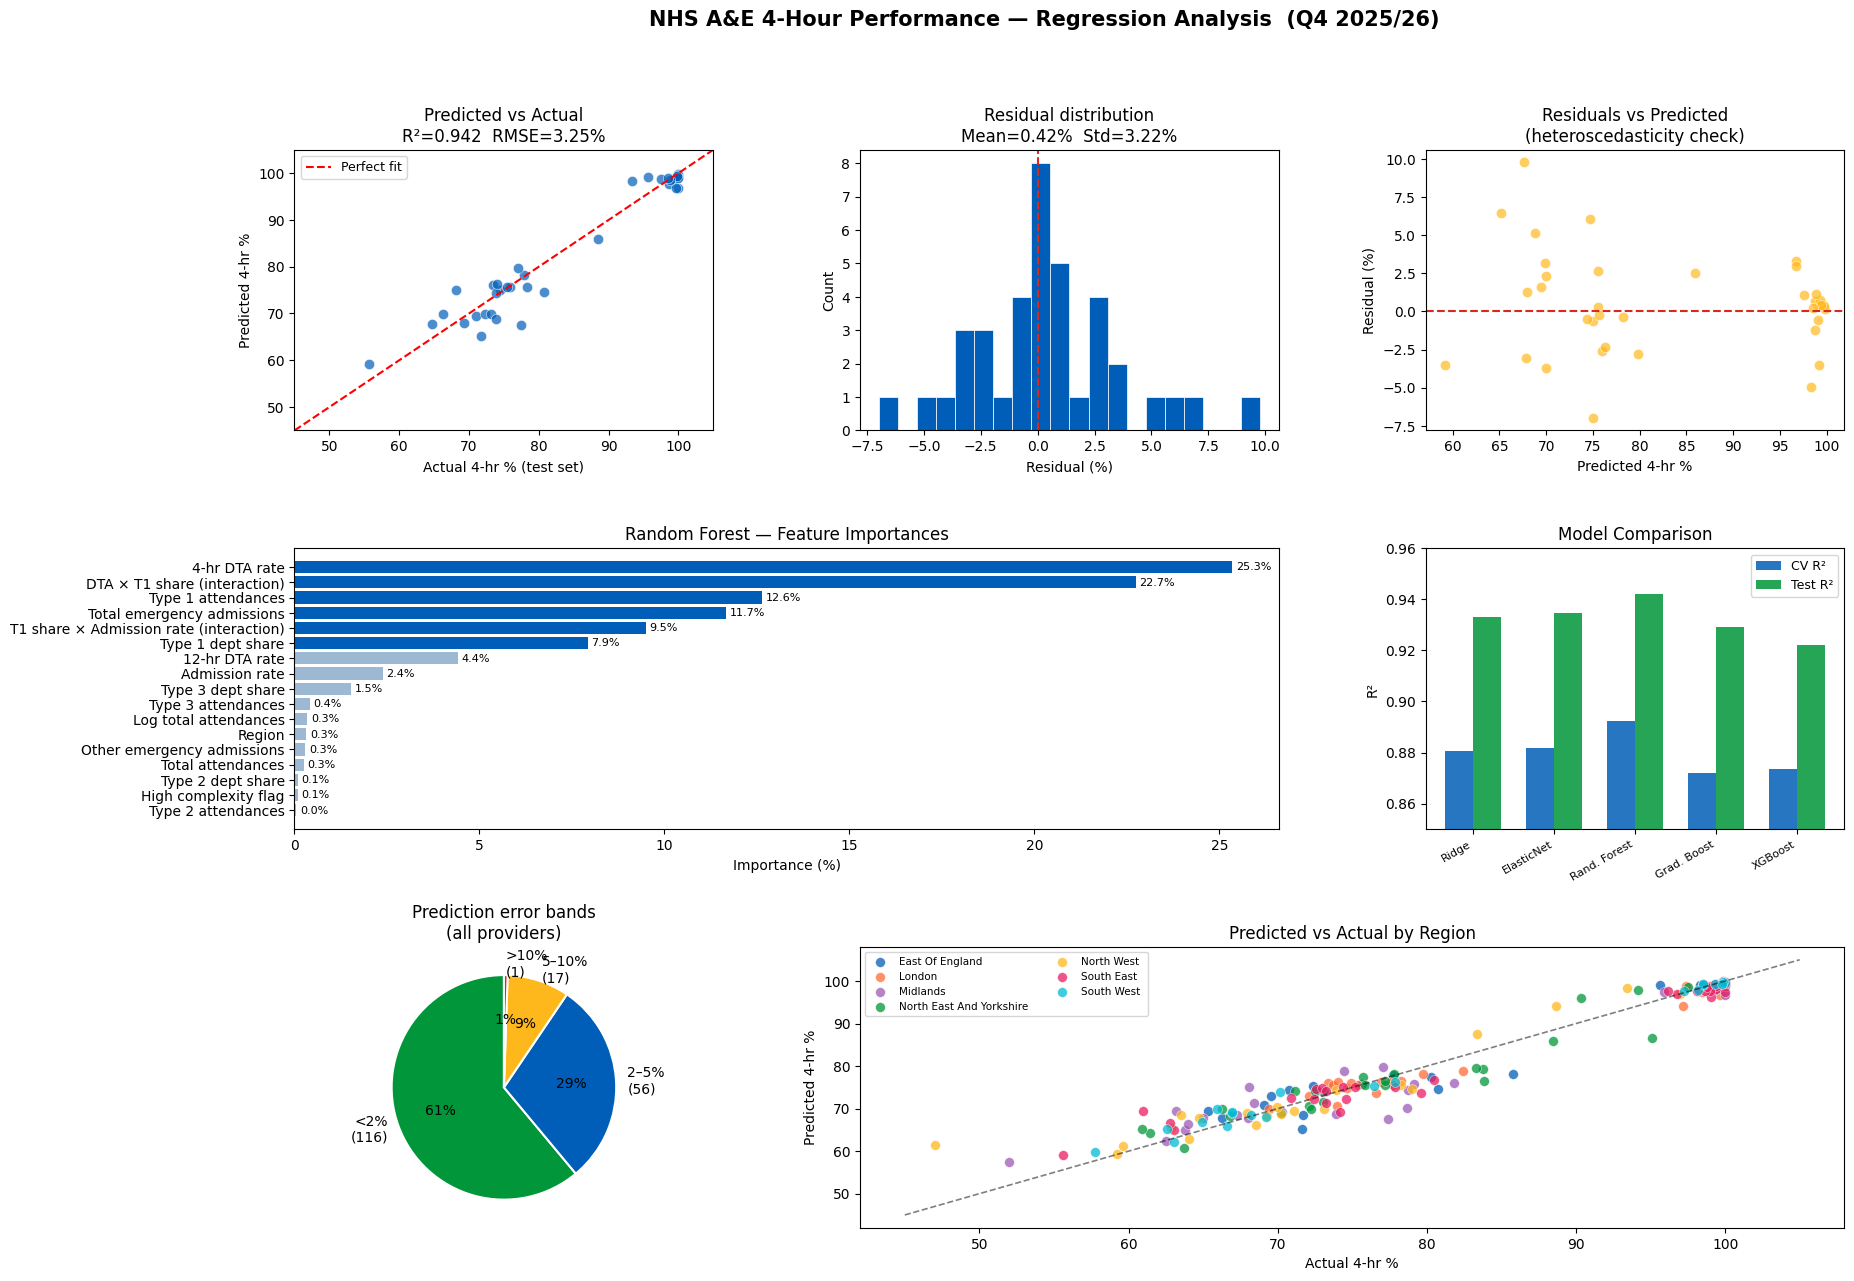

In [8]:
print("\nGenerating plots...")

C_BLUE = "#005EB8"; C_GREEN = "#009639"; C_RED = "#DA291C"; C_AMB = "#FFB81C"

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle("NHS A&E 4-Hour Performance — Regression Analysis  (Q4 2025/26)",
             fontsize=15, fontweight="bold", y=0.98)

y_pred_test = best_res["pred_test"]
y_pred_all  = np.clip(best_mdl.predict(X_full), 0, 1)

# Plot 1: Predicted vs Actual
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_te * 100, y_pred_test * 100, alpha=0.7, color=C_BLUE,
            edgecolors="white", linewidths=0.5, s=55)
lims = [45, 105]
ax1.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("Actual 4-hr % (test set)")
ax1.set_ylabel("Predicted 4-hr %")
ax1.set_title(f"Predicted vs Actual\nR²={results[best_name]['r2']:.3f}  RMSE={results[best_name]['rmse']:.2f}%")
ax1.legend(fontsize=9)

# Plot 2: Residuals distribution
ax2 = fig.add_subplot(gs[0, 1])
res_pct = (y_te.values - y_pred_test) * 100
ax2.hist(res_pct, bins=20, color=C_BLUE, edgecolor="white", linewidth=0.5)
ax2.axvline(0, color=C_RED, linestyle="--", lw=1.5)
ax2.set_xlabel("Residual (%)")
ax2.set_ylabel("Count")
ax2.set_title(f"Residual distribution\nMean={np.mean(res_pct):.2f}%  Std={np.std(res_pct):.2f}%")

# Plot 3: Residuals vs Predicted
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(y_pred_test * 100, res_pct, alpha=0.7, color=C_AMB,
            edgecolors="white", linewidths=0.5, s=55)
ax3.axhline(0, color=C_RED, linestyle="--", lw=1.5)
ax3.set_xlabel("Predicted 4-hr %")
ax3.set_ylabel("Residual (%)")
ax3.set_title("Residuals vs Predicted\n(heteroscedasticity check)")

# Plot 4: Feature importances
ax4 = fig.add_subplot(gs[1, 0:2])
fi_plot = pd.Series(rf_mdl.feature_importances_, index=FEATURES)
fi_plot.index = [fi_labels.get(i, i) for i in fi_plot.index]
fi_plot = fi_plot.sort_values()
bar_colors = [C_BLUE if v > 0.05 else "#9db8d2" for v in fi_plot.values]
ax4.barh(fi_plot.index, fi_plot.values * 100, color=bar_colors, edgecolor="none")
ax4.set_xlabel("Importance (%)")
ax4.set_title("Random Forest — Feature Importances")
for i, v in enumerate(fi_plot.values * 100):
    ax4.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)

# Plot 5: Model comparison
ax5 = fig.add_subplot(gs[1, 2])
model_names_short = ["Ridge", "ElasticNet", "Rand. Forest", "Grad. Boost", "XGBoost"]
cv_r2s   = [results[n]["cv_r2"]  for n in results]
test_r2s = [results[n]["r2"]     for n in results]
x = np.arange(len(model_names_short))
w = 0.35
ax5.bar(x - w/2, cv_r2s,   w, label="CV R²",   color=C_BLUE,  alpha=0.85)
ax5.bar(x + w/2, test_r2s, w, label="Test R²",  color=C_GREEN, alpha=0.85)
ax5.set_xticks(x)
ax5.set_xticklabels(model_names_short, rotation=30, ha="right", fontsize=8)
ax5.set_ylabel("R²")
ax5.set_ylim(0.85, 0.96)
ax5.set_title("Model Comparison")
ax5.legend(fontsize=9)

# Plot 6: Error band pie
ax6 = fig.add_subplot(gs[2, 0])
abs_err = np.abs(y.values - y_pred_all) * 100
bands  = ["<2%", "2–5%", "5–10%", ">10%"]
counts = [
    (abs_err < 2).sum(),
    ((abs_err >= 2) & (abs_err < 5)).sum(),
    ((abs_err >= 5) & (abs_err < 10)).sum(),
    (abs_err >= 10).sum(),
]
ax6.pie(counts,
        labels=[f"{b}\n({c})" for b, c in zip(bands, counts)],
        colors=[C_GREEN, C_BLUE, C_AMB, C_RED],
        autopct="%1.0f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax6.set_title("Prediction error bands\n(all providers)")

# Plot 7: Predicted vs Actual by Region
ax7 = fig.add_subplot(gs[2, 1:])
region_short = df_m["Region"].str.replace("NHS England ", "")
palette = [C_BLUE, "#FF6B35", "#9B59B6", C_GREEN, C_AMB, "#E91E63", "#00BCD4"]
for i, reg in enumerate(sorted(region_short.unique())):
    mask = region_short == reg
    ax7.scatter(df_m.loc[mask, "pct_within_4h_all"] * 100,
                y_pred_all[mask] * 100,
                label=reg, alpha=0.75,
                color=palette[i % len(palette)], s=50,
                edgecolors="white", linewidths=0.4)
ax7.plot([45, 105], [45, 105], "k--", lw=1.2, alpha=0.5)
ax7.set_xlabel("Actual 4-hr %")
ax7.set_ylabel("Predicted 4-hr %")
ax7.set_title("Predicted vs Actual by Region")
ax7.legend(fontsize=7.5, ncol=2, loc="upper left")

In [9]:
plt.savefig(DATA_DIR + "nhs_ae_regression_plots.png", dpi=150, bbox_inches="tight")
print("  Plots saved → nhs_ae_regression_plots.png")
plt.close()

print("\nDone! ✅")


  Plots saved → nhs_ae_regression_plots.png

Done! ✅
